# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [ ]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.9 MB/s eta 0:00:00
✅ Dependencies ready


In [ ]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [ ]:
# Label map for TakeMeter — Hacker News comment discourse quality.
# substantive: engages with specifics, reasoning, or firsthand experience.
# dismissive: low-effort negativity/snark with no supporting argument.
# hype: enthusiastic, low-substance boosterism about a product/company.

LABEL_MAP = {
    "substantive": 0,
    "dismissive": 1,
    "hype": 2,
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'substantive': 0, 'dismissive': 1, 'hype': 2}
Number of labels: 3


In [ ]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving takemeter_dataset.csv to takemeter_dataset.csv
Uploaded: takemeter_dataset.csv


In [ ]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label', 'notes']
Total examples: 255

Label distribution:
label
substantive    175
hype            42
dismissive      38
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [ ]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 178 examples
Validation: 38 examples
Test: 39 examples

Train label distribution:
label
substantive    122
hype            29
dismissive      27
Name: count, dtype: int64

Test label distribution:
label
substantive    27
hype            7
dismissive      5
Name: count, dtype: int64


In [ ]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/178 [00:00<?, ? examples/s]

Map:   0%|          | 0/38 [00:00<?, ? examples/s]

Map:   0%|          | 0/39 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [ ]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.101300,1.066648,0.710526
2,1.043153,0.941964,0.684211
3,0.922287,0.725752,0.684211


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [ ]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.744

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

 substantive       0.88      0.85      0.87        27
  dismissive       0.00      0.00      0.00         5
        hype       0.46      0.86      0.60         7

    accuracy                           0.74        39
   macro avg       0.45      0.57      0.49        39
weighted avg       0.70      0.74      0.71        39



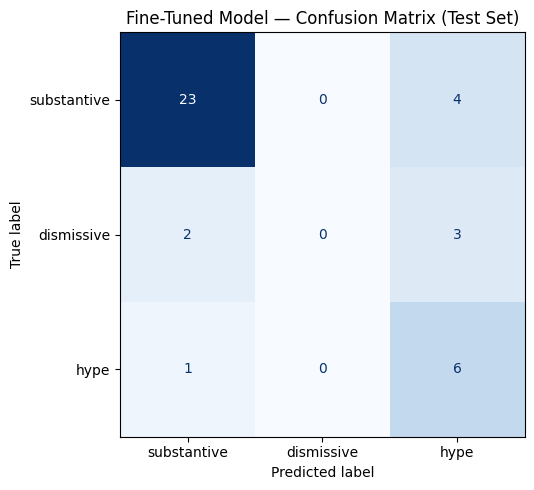

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [ ]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [ ]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 10 / 39

--- #1 ---
Text:      Chevron and Microsoft agree to keep smoking crack and buy it for each other when needed and not tell anyone.
True:      dismissive
Predicted: substantive  (confidence: 0.35)

--- #2 ---
Text:      Which work has more value: the abstract description of a catalogue of potential model architectures or their validated application trained on real data?
In the Schmidhuber case their is 20 years and a...
True:      substantive
Predicted: hype  (confidence: 0.35)

--- #3 ---
Text:      a lot of words and no idea of the practical benefit.
Awesome in the biblical sense.
True:      dismissive
Predicted: hype  (confidence: 0.36)

--- #4 ---
Text:      I haven’t seen much on WebMCP adoption yet, but I’ve been keen to use it for improving the AX of a web app at work. I’m curious how you all are seeing it be used.
True:      substantive
Predicted: hype  (confidence: 0.35)

--- #5 ---
Text:      i've been using hackfeed, it does the job.
make this avai

---
## Section 4b (Stretch): Confidence Calibration

Buckets predictions by the model's own confidence score and checks whether higher
confidence actually corresponds to higher accuracy — i.e. whether the confidence
scores are meaningful rather than just noise alongside the prediction.

In [ ]:
# Confidence calibration: does a 90%-confident prediction get it right more
# often than a 60%-confident one?
ft_confidences = ft_probs[np.arange(len(ft_pred_ids)), ft_pred_ids]
ft_correct = (ft_pred_ids == ft_true_ids)

bins = [0.0, 0.5, 0.7, 0.85, 1.0]
bin_labels = ["<0.50", "0.50-0.70", "0.70-0.85", "0.85-1.00"]

calibration_rows = []
for lo, hi, name in zip(bins[:-1], bins[1:], bin_labels):
    mask = (ft_confidences >= lo) & (ft_confidences < hi if hi < 1.0 else ft_confidences <= hi)
    n = mask.sum()
    acc = ft_correct[mask].mean() if n > 0 else float("nan")
    calibration_rows.append((name, n, acc))

print("Confidence calibration (fine-tuned model, test set):")
print(f"{'Confidence bucket':<18}{'N':>6}{'Accuracy':>12}")
for name, n, acc in calibration_rows:
    acc_str = f"{acc:.3f}" if n > 0 else "n/a"
    print(f"{name:<18}{n:>6}{acc_str:>12}")

calibration_summary = [
    {"bucket": name, "n": int(n), "accuracy": (None if n == 0 else round(float(acc), 4))}
    for name, n, acc in calibration_rows
]
print("\nUse this table in your README's stretch-feature section.")

Confidence calibration (fine-tuned model, test set):
Confidence bucket      N    Accuracy
<0.50                 39       0.744
0.50-0.70              0         n/a
0.70-0.85              0         n/a
0.85-1.00              0         n/a

Use this table in your README's stretch-feature section.


---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [32]:
from groq import Groq
from google.colab import userdata

# Get key from Colab Secrets panel
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel "
    "(🔑 icon in the left sidebar) and enable notebook access."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [33]:
SYSTEM_PROMPT = """
You are classifying comments from Hacker News (a tech-focused online discussion forum).
Assign each comment to exactly one of the following categories.

substantive: The comment engages with the specifics of the post or thread using
reasoning, evidence, or firsthand experience, even if brief.
Example: "I ran this exact migration at my last job on a 40M row table — the issue
isn't the index, it's that the ALTER TABLE takes a write lock for the full duration
on MySQL 5.7. You want pt-online-schema-change or to wait for 8.0's instant DDL."

dismissive: Low-effort negativity or snark about the post/topic that contains no
supporting argument, evidence, or specific reasoning — it rejects without engaging.
Example: "This again? We've seen this exact post six times this year."

hype: Enthusiastic, boosterish reaction to a product, company, or technology that
contains no specific reasoning or evidence beyond excitement.
Example: "This is going to change everything. Incredible work, can't wait to see
where this goes!"

Important: a comment that is enthusiastic but contains a specific, checkable claim
(a number, a named mechanism, a firsthand test) is substantive, not hype — specificity
matters more than tone. The same applies to harsh-but-specific criticism: it is
substantive, not dismissive, if it gives a real reason.

Respond with ONLY the label name. Do not explain your reasoning.

Valid labels:
substantive
dismissive
hype
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1441 characters


In [34]:
import httpx
r = httpx.get("https://api.groq.com")
print(r.status_code)

200


In [35]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 39 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/39 complete...
  20/39 complete...
  30/39 complete...


In [36]:

# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.923  (evaluated on 39/39 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

 substantive       0.93      0.96      0.95        27
  dismissive       1.00      0.80      0.89         5
        hype       0.86      0.86      0.86         7

    accuracy                           0.92        39
   macro avg       0.93      0.87      0.90        39
weighted avg       0.92      0.92      0.92        39



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [37]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.923
Fine-tuned DistilBERT                  0.744
---------------------------------------------

Fine-tuning regression: 0.179

Use these numbers in your README evaluation report.


In [38]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
    "confidence_calibration": calibration_summary,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download


---
## Section 7 (Stretch): Deployed Interface

A minimal interface that takes a new HN-style comment and shows the fine-tuned
model's predicted label and confidence. Runs directly in this Colab session — no
separate hosting needed. Take a screenshot or a short screen recording of this for
your demo video.

In [39]:
!pip install -q gradio
import gradio as gr

def classify_new_comment(text):
    if not text or not text.strip():
        return "Enter a comment to classify."
    inputs = tokenizer(text, truncation=True, max_length=256, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)[0].cpu().numpy()
    pred_id = int(np.argmax(probs))
    pred_label = ID_TO_LABEL[pred_id]
    confidence = float(probs[pred_id])
    breakdown = "\n".join(
        f"  {ID_TO_LABEL[i]}: {probs[i]:.3f}" for i in range(NUM_LABELS)
    )
    return f"Predicted label: {pred_label}\nConfidence: {confidence:.3f}\n\nAll class probabilities:\n{breakdown}"

demo = gr.Interface(
    fn=classify_new_comment,
    inputs=gr.Textbox(lines=4, placeholder="Paste a Hacker News-style comment here..."),
    outputs=gr.Textbox(label="TakeMeter prediction"),
    title="TakeMeter — HN Discourse Classifier",
    description="Classifies a comment as substantive / dismissive / hype using the fine-tuned DistilBERT model.",
)
demo.launch(debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7ddc263d18901a502b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
